In [33]:
# Импортируем библиотеки

import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split

In [34]:
# Присвоим переменной «url» ссылку на датасет:

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data"



# создаем лист с названием столбцов:
cols = ['Sex','Lenght','Diameter','Height','Whole_weight',
        'Shucked_weight','Viscera_weight','Shell_weight','Rings']

# используем Pandas read_csv():
df = pd.read_csv(url, names=cols)



In [35]:
vals = df["Sex"].unique()
vals


array(['M', 'F', 'I'], dtype=object)

In [36]:
# сохраняем только числовые столбцы. Категориальные кодируем в числовые. Целевую переменную (если она есть) - убираем
cols_for_clusters = ['Lenght','Diameter','Height','Whole_weight',
        'Shucked_weight','Viscera_weight','Shell_weight','Rings']

data= df[cols_for_clusters].copy() # делаем копию, чтобы не было сюрпризов с исходным набором данных

In [37]:
data.head()


,Lenght,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [38]:
X = data
y = df["Sex"].replace(vals, [0, 1, 2])
yvals = df["Sex"]

/tmp/ipykernel_19198/2502289525.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = df["Sex"].replace(vals, [0, 1, 2])


In [39]:
import mpl_toolkits.mplot3d  # noqa: F401
from sklearn.cluster import KMeans

X["Diameter"], X["Rings"], X["Shell_weight"]

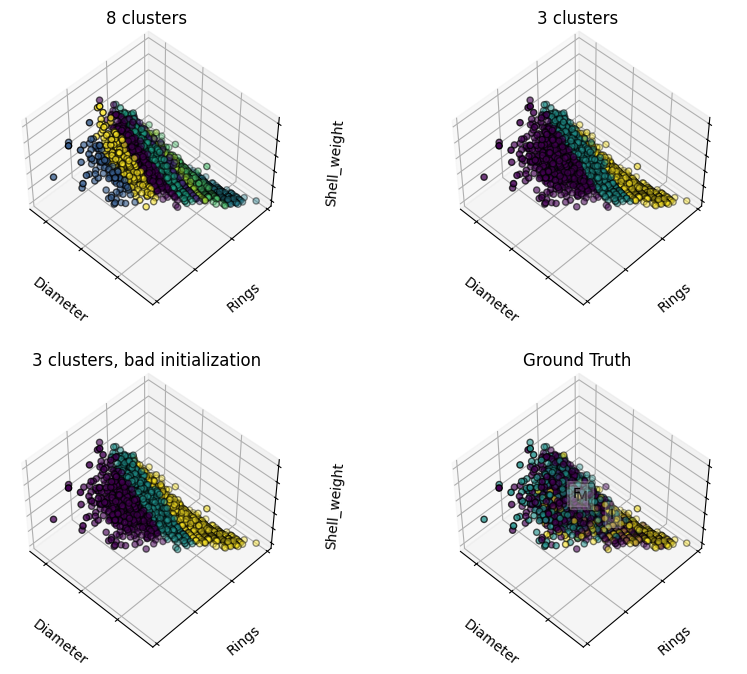

In [40]:
estimators = [
    ("k_means_iris_8", KMeans(n_clusters=8)),
    ("k_means_iris_3", KMeans(n_clusters=3)),
    ("k_means_iris_bad_init", KMeans(n_clusters=3, n_init=1, init="random")),
]

fig = plt.figure(figsize=(10, 8))
titles = ["8 clusters", "3 clusters", "3 clusters, bad initialization"]
for idx, ((name, est), title) in enumerate(zip(estimators, titles)):
    ax = fig.add_subplot(2, 2, idx + 1, projection="3d", elev=48, azim=134)
    est.fit(X)
    labels = est.labels_

    ax.scatter(X["Diameter"], X["Rings"], X["Shell_weight"], c=labels.astype(float), edgecolor="k")

    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])
    ax.zaxis.set_ticklabels([])
    ax.set_xlabel("Diameter")
    ax.set_ylabel("Rings")
    ax.set_zlabel("Shell_weight")
    ax.set_title(title)

# Plot the ground truth
ax = fig.add_subplot(2, 2, 4, projection="3d", elev=48, azim=134)

for name, label in [(vals[0], 0), (vals[1], 1), (vals[2], 2)]:
    ds = df[df["Sex"]==name]
    ax.text3D(
        ds["Diameter"].mean(),
        ds["Rings"].mean(),
        ds["Shell_weight"].mean(),
        name,
        horizontalalignment="center",
        bbox=dict(alpha=0.2, edgecolor="w", facecolor="w"),
    )

ax.scatter(X["Diameter"], X["Rings"], X["Shell_weight"], c=y, edgecolor="k")

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel("Diameter")
ax.set_ylabel("Rings")
ax.set_zlabel("Shell_weight")
ax.set_title("Ground Truth")

plt.subplots_adjust(wspace=0.25, hspace=0.25)
plt.show()

In [41]:

from sklearn import metrics
from sklearn.metrics.cluster import adjusted_rand_score


n_clusters = np.arange(2, 21)


In [42]:
best_metric = [0, 10000, 0,[]]

silhouette_score_values = []
adjusted_rand_score_values = []


for n in n_clusters:

    clusterer = KMeans(n_clusters=n, max_iter=10, n_init=10)
    clusterer.fit(X)
    y_pred = clusterer.predict(X)

    score1 = metrics.silhouette_score(X, y_pred)
    silhouette_score_values.append(score1)

    score2 = metrics.adjusted_rand_score(y, y_pred)
    adjusted_rand_score_values.append(score2)


    if score1 < best_metric[1] and score2 > best_metric[2]:
          best_metric[1] = score1
          best_metric[2] = score2
          best_metric[3] = clusterer.cluster_centers_
          best_metric[0] = n



In [43]:
best_metric

[np.int64(3),
 np.float64(0.514652571633363),
 0.13312873948546589,
 array([[ 0.42099147,  0.32127576,  0.10659559,  0.4323742 ,  0.198199  ,
          0.09335714,  0.12139446,  6.88415068],
        [ 0.57364035,  0.44874342,  0.15363377,  1.00693048,  0.44330066,
          0.22172434,  0.28465482, 10.4127193 ],
        [ 0.58873469,  0.46642857,  0.16835714,  1.13776327,  0.4316051 ,
          0.23970306,  0.36281939, 16.46122449]])]

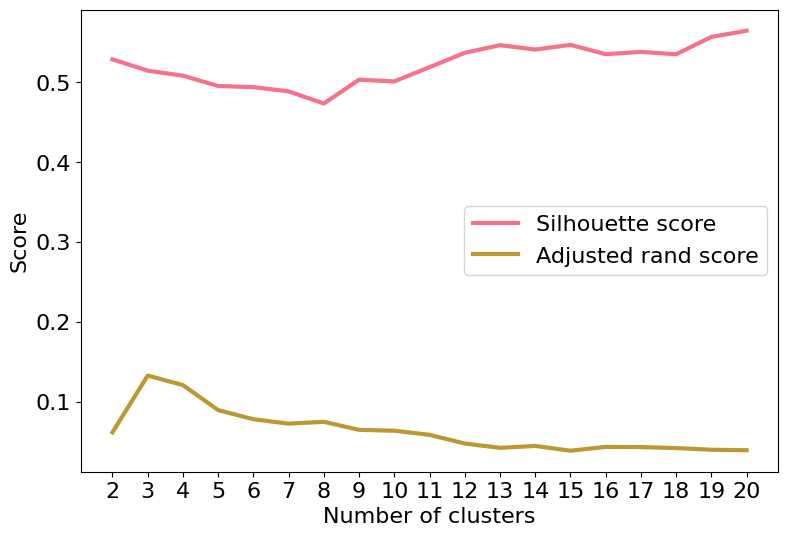

In [44]:
plt.figure(figsize=(9, 6))
plt.plot(n_clusters, silhouette_score_values, linewidth=3, label='Silhouette score')
plt.plot(n_clusters, adjusted_rand_score_values, linewidth=3, label='Adjusted rand score')
plt.xlabel('Number of clusters', size=16)
plt.ylabel('Score', size=16)
plt.xticks(n_clusters, size=16)
plt.yticks(size=16)
plt.legend(loc='best', fontsize=16)

plt.show()


#plt.figure(figsize=(9, 6))
#plt.plot(n_clusters, within_cluster_dist_values, linewidth=3, label='Within-cluster distance')
#plt.xlabel('Number of clusters', size=16)
#plt.ylabel('Score', size=16)
#plt.xticks(n_clusters, size=16)
#plt.yticks(size=16)
#plt.legend(loc='best', fontsize=16)

#plt.show()

In [45]:
from scipy.cluster.hierarchy import linkage, dendrogram

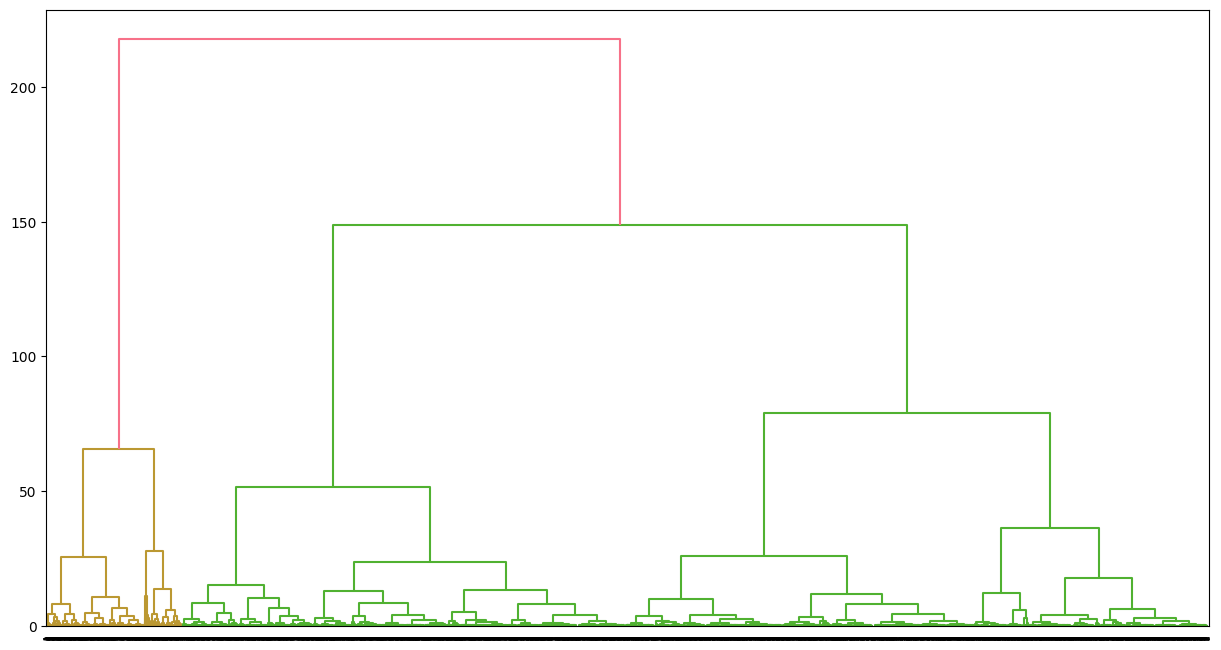

In [47]:
samples = data.values

# Реализация иерархической кластеризации при помощи функции linkage
mergings = linkage(samples, method='ward')
# попробуйте с другими методами
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html

plt.figure(figsize=(15, 8))
# Строим дендрограмму, указав параметры удобные для отображения
dendrogram(mergings,
           labels=list(y),
           leaf_rotation=90,
           leaf_font_size=5,
           )

plt.show()


In [54]:
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

In [55]:
mins = X.shape[1]

['y', 'b', 'g', 'r']


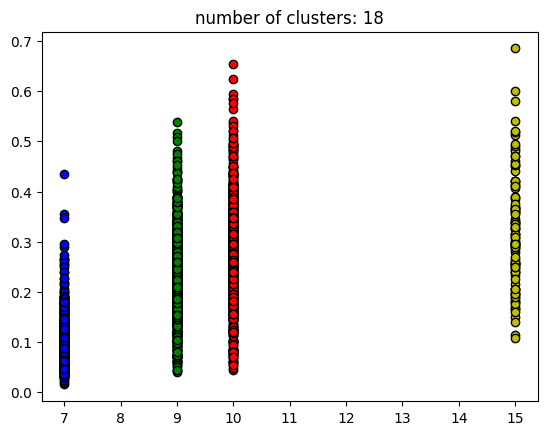

In [56]:
db = DBSCAN(eps=0.5, min_samples=12).fit(X)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

# Plot result

# Black removed and is used for noise instead.
unique_labels = set(labels)
colors = ['y', 'b', 'g', 'r']
print(colors)
for k, col in zip(unique_labels, colors):
	if k == -1:
		# Black used for noise.
		col = 'k'

	class_member_mask = (labels == k)

	xy = X[class_member_mask & core_samples_mask]
	plt.plot(xy["Rings"], xy["Shell_weight"], 'o', markerfacecolor=col,
			markeredgecolor='k',
			markersize=6)

	xy = X[class_member_mask & ~core_samples_mask]
	plt.plot(xy["Rings"], xy["Shell_weight"], 'o', markerfacecolor=col,
			markeredgecolor='k',
			markersize=6)

plt.title('number of clusters: %d' % n_clusters_)
plt.show()


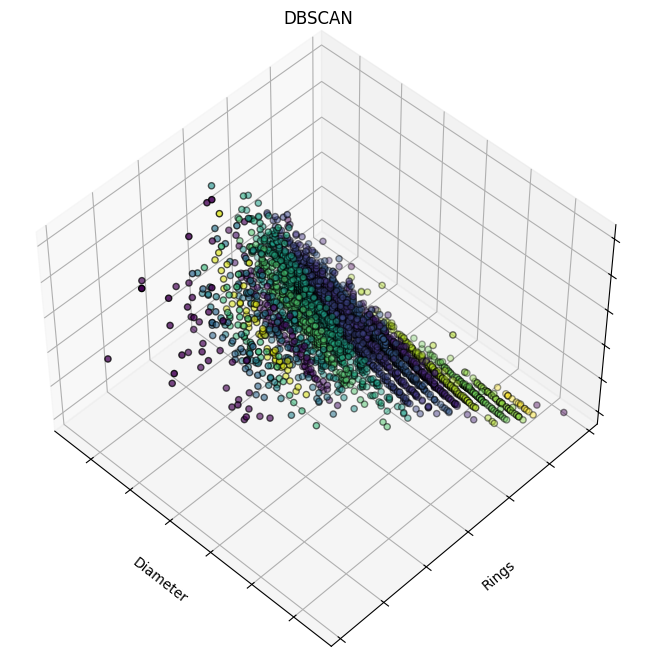

In [57]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection="3d", elev=48, azim=134)

ax.scatter(X["Diameter"], X["Rings"], X["Shell_weight"], c=labels.astype(float), edgecolor="k")

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel("Diameter")
ax.set_ylabel("Rings")
ax.set_zlabel("Shell_weight")
ax.set_title("DBSCAN")

plt.show()


In [58]:

# evaluation metrics
sc = metrics.silhouette_score(X, labels)
print("Silhouette Coefficient:%0.2f" % sc)
ari = adjusted_rand_score(y, labels)
print("Adjusted Rand Index: %0.2f" % ari)

Silhouette Coefficient:0.57
Adjusted Rand Index: 0.04


Методы кластеризации хорошо выделяют структуру в данных (высокие Silhouette Coefficient), но не могут предсказать пол моллюсков (низкие ARI). Это ожидаемо, так как пол биологически не должен сильно коррелировать с размерами - самцы и самки морского ушка могут иметь схожие размерные характеристики